# IC Spike times and LFP

## Importing the Libraries and the Paths in case of Notebook Re-Run

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import seaborn as sns
%matplotlib widget

import spikeinterface as si
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.widgets as sw

In [2]:
# Data paths
# SP1
sp1_path = Path("/Volumes/AFedor_T7/TTK-NeuroData/sp_1_20171017/spike_sorting_Thresh_9_9/Data/")
# SP6
sp6_path = Path("/Volumes/AFedor_T7/TTK-NeuroData/sp_6_20180628/spike_sorting_Thresh_9_9/Data/")
# SP7
sp7_path = Path("/Volumes/AFedor_T7/TTK-NeuroData/sp_7_20190305/spike_sorting_Thresh_9_9/Data/")
# SP9
sp9_path = Path("/Volumes/AFedor_T7/TTK-NeuroData/sp_9_20220215/spike_sorting_Thresh_9_9/Data/")

In [3]:
# Filtered LFP paths
filtered_lfp_paths = {
    "sp1_01": "/Volumes/AFedor_T7/TTK-NeuroData/LFP codes/cached/own_data/sp1_01/optimal",
    "sp1_02": "/Volumes/AFedor_T7/TTK-NeuroData/LFP codes/cached/own_data/sp1_02/optimal",
    "sp1_03": "/Volumes/AFedor_T7/TTK-NeuroData/LFP codes/cached/own_data/sp1_03/optimal",
    "sp1_04": "/Volumes/AFedor_T7/TTK-NeuroData/LFP codes/cached/own_data/sp1_04/optimal",
    "sp6_01": "/Volumes/AFedor_T7/TTK-NeuroData/LFP codes/cached/own_data/sp6_01/optimal",
    "sp6_02": "/Volumes/AFedor_T7/TTK-NeuroData/LFP codes/cached/own_data/sp6_02/optimal",
    "sp6_03": "/Volumes/AFedor_T7/TTK-NeuroData/LFP codes/cached/own_data/sp6_03/optimal",
    "sp6_04": "/Volumes/AFedor_T7/TTK-NeuroData/LFP codes/cached/own_data/sp6_04/optimal",
    "sp7_01": "/Volumes/AFedor_T7/TTK-NeuroData/LFP codes/cached/own_data/sp7_01/optimal",
    "sp7_02": "/Volumes/AFedor_T7/TTK-NeuroData/LFP codes/cached/own_data/sp7_02/optimal",
    "sp9_01": "/Volumes/AFedor_T7/TTK-NeuroData/LFP codes/cached/own_data/sp9_01/optimal",
    "sp9_02": "/Volumes/AFedor_T7/TTK-NeuroData/LFP codes/cached/own_data/sp9_02/optimal",
    "sp9_03": "/Volumes/AFedor_T7/TTK-NeuroData/LFP codes/cached/own_data/sp9_03/optimal",
}

## Load the Filtered Recordings from the Cached Folder

In [4]:
# Load the recordings from the cache to save time in case the notebook is re-run
recordings = dict()
for path in filtered_lfp_paths.keys():
    recording_name = path
    print(f"Loading recording: {recording_name}")
    recordings[recording_name] = si.load(filtered_lfp_paths[path])

Loading recording: sp1_01
Loading recording: sp1_02
Loading recording: sp1_03
Loading recording: sp1_04
Loading recording: sp6_01
Loading recording: sp6_02
Loading recording: sp6_03
Loading recording: sp6_04
Loading recording: sp7_01
Loading recording: sp7_02
Loading recording: sp9_01
Loading recording: sp9_02
Loading recording: sp9_03


In [5]:
n_ch = 32
for rec in recordings.keys():
    recordings[rec].set_property("gain_to_uV", [1.0] * n_ch)
    recordings[rec].set_property("offset_to_uV", [0.0] * n_ch)

## Load IC Spike times from .ev2

In [6]:
# Define the folders for each dataset - .ev2 files are in the root of each folder, and the .dat files are in the Data subfolder
sp1_folder = Path("/Volumes/AFedor_T7/TTK-NeuroData/sp_1_20171017/")
sp6_folder = Path("/Volumes/AFedor_T7/TTK-NeuroData/sp_6_20180628/")
sp7_folder = Path("/Volumes/AFedor_T7/TTK-NeuroData/sp_7_20190305/")
sp9_folder = Path("/Volumes/AFedor_T7/TTK-NeuroData/sp_9_20220215/")

In [7]:
# Loading the IC spike times from the .ev2 event files for further analysis
sp9_ic_spike_times = {}
for recording_id in ['01', '02', '03']:
    ev2_file = sp9_folder / f"{recording_id}.ev2"
    ic_spike_times = np.loadtxt(ev2_file, usecols=5)
    sp9_ic_spike_times[recording_id] = ic_spike_times

print(sp9_ic_spike_times["01"].shape)
print(sp9_ic_spike_times["01"][:10]) # Print the first 10 spike times for recording 01
print(sp9_ic_spike_times["01"].dtype) 

(822,)
[ 4656.  8853. 12194. 20113. 27679. 31673. 36495. 40604. 51191. 53646.]
float64


## Visualize IC spikes on the LFP

Use the 20kHz filtered LFP recordings and the IC spike times for visualizing the patched cell's activity in relation to the LFP. 

The IC spike times can be used to align the LFP traces to the spikes, allowing for analysis of the relationship between the two signals.

In [8]:
# The IC spike times are in data points. 20kHz sampling rate and 180s recording duration.
# Convert the IC spike times into seconds for indexing
sp9_ic_spike_times_sec = {k: v / 20000.0 for k, v in sp9_ic_spike_times.items()}
print(sp9_ic_spike_times_sec["01"].dtype)
print(sp9_ic_spike_times_sec["01"][:10])

float64
[0.2328  0.44265 0.6097  1.00565 1.38395 1.58365 1.82475 2.0302  2.55955
 2.6823 ]


Text(0.5, 0, 'Time (s)')

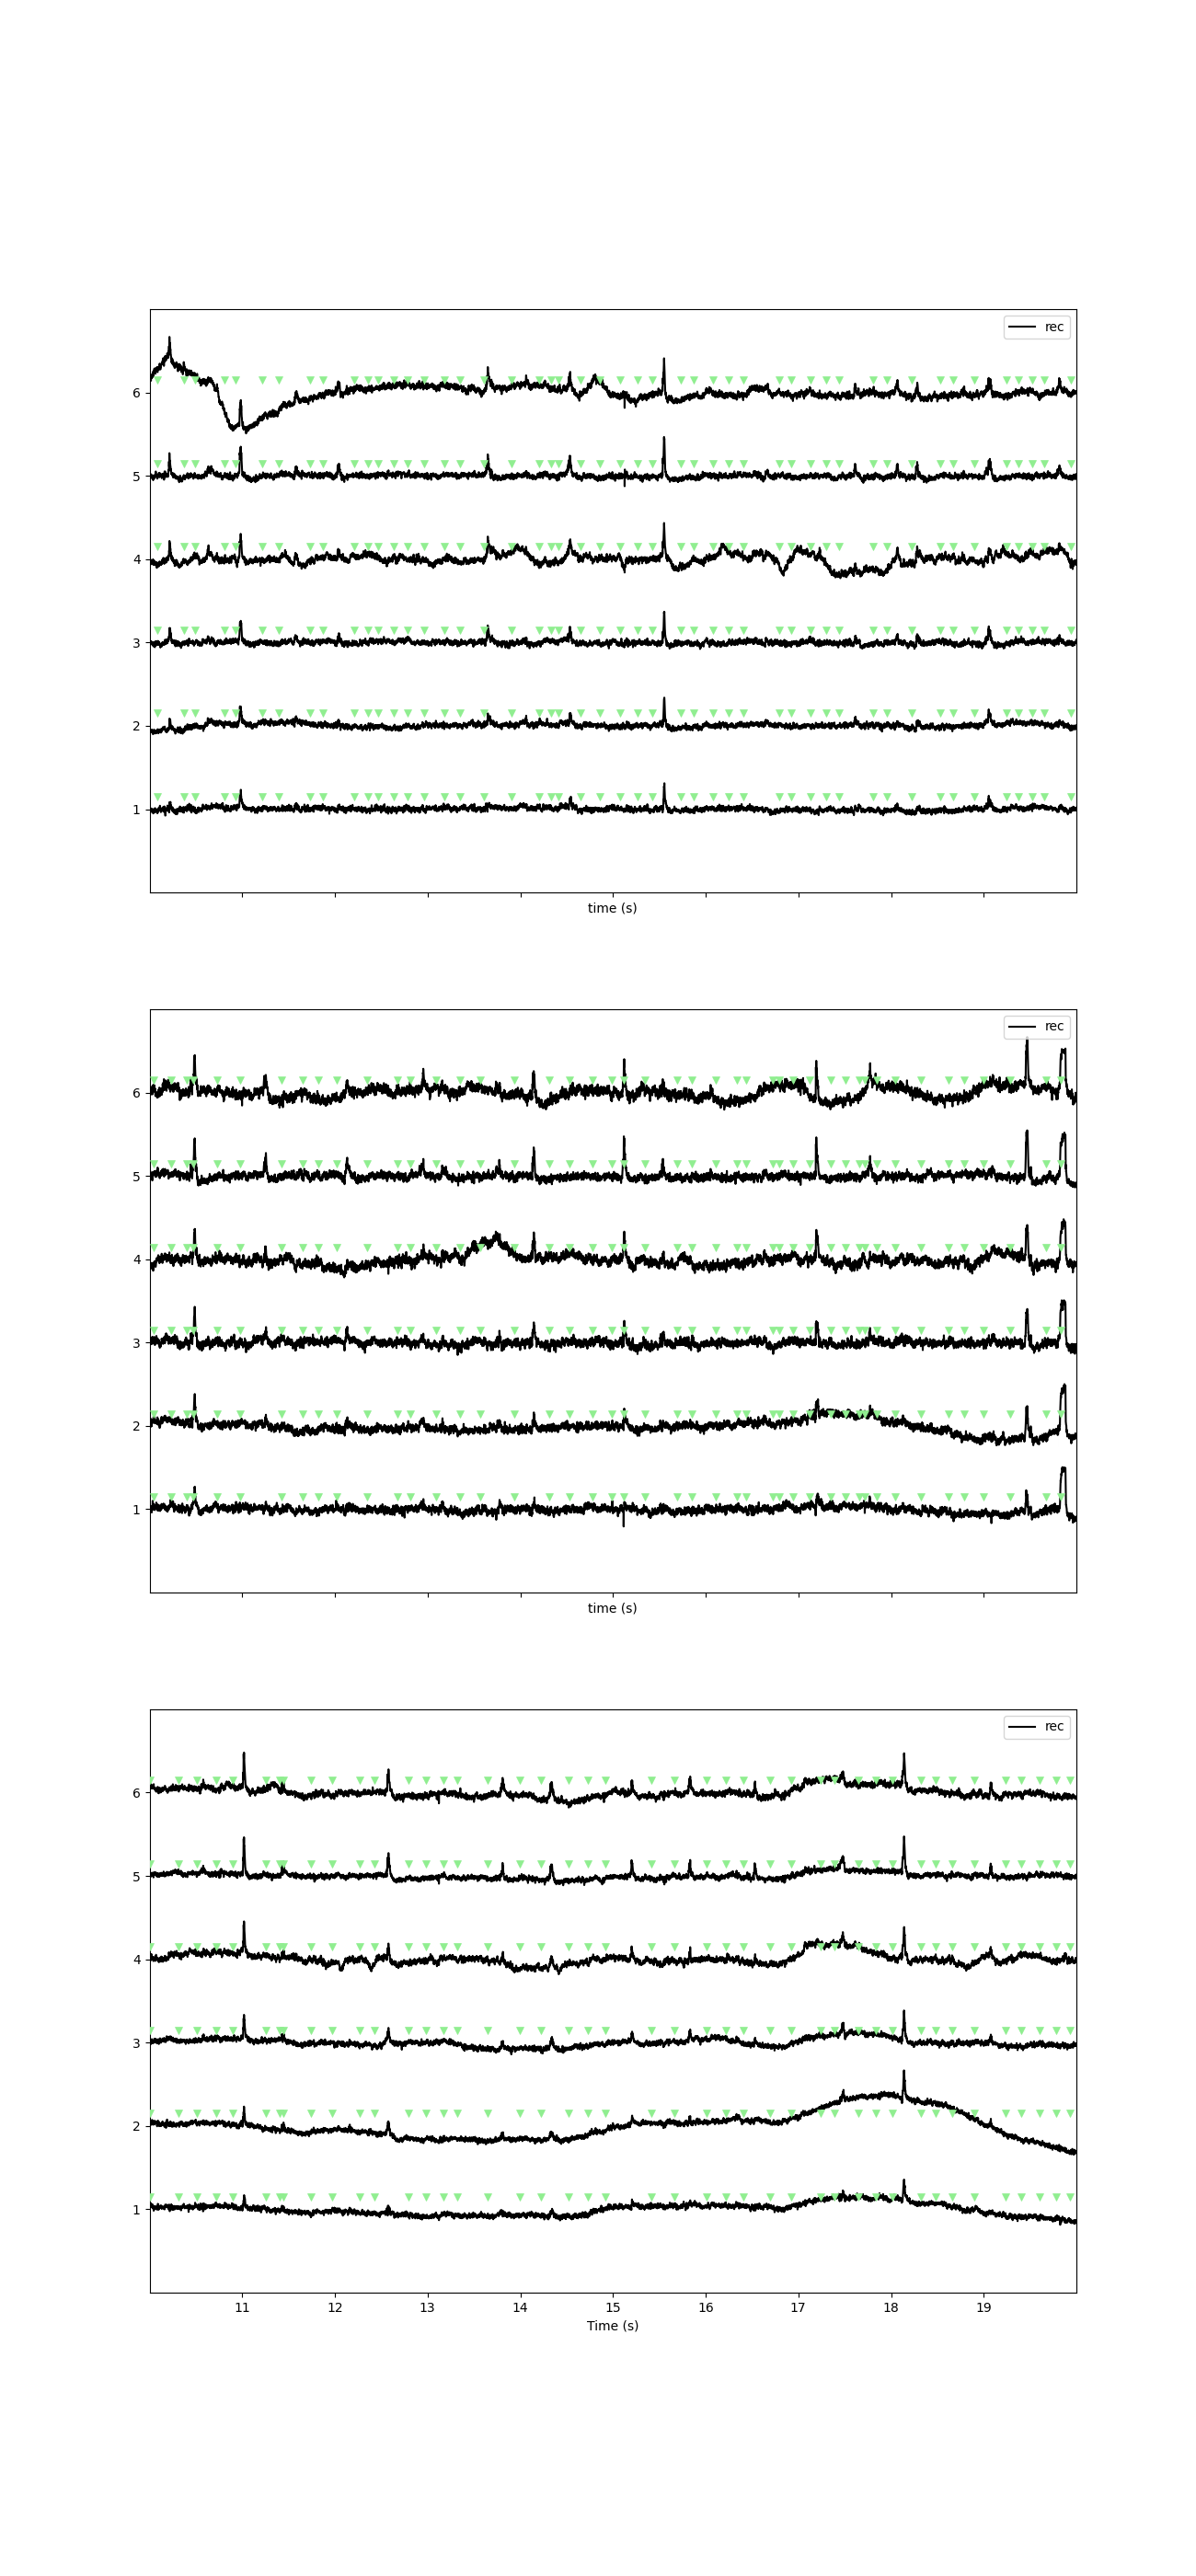

In [12]:
# Plot the 20kHz filtered LFP traces and mark the IC spike times on the plot for the recordings of SP9
channels_to_plot = [1, 2, 3, 4, 5, 6]  # Specify the channels you want to plot
time_window = [10, 20]  # Specify the time window in seconds for plotting

fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(13, 28), sharex=True)
sw.plot_traces(recordings["sp9_01"], ax=axs[0], channel_ids=channels_to_plot, show_channel_ids=True, time_range=time_window)
sw.plot_traces(recordings["sp9_02"], ax=axs[1], channel_ids=channels_to_plot, show_channel_ids=True, time_range=time_window)
sw.plot_traces(recordings["sp9_03"], ax=axs[2], channel_ids=channels_to_plot, show_channel_ids=True, time_range=time_window)

# Place a small v-shaped marker slightly above the baseline of every rendered trace.
for ax, recording_id in zip(axs, ["01", "02", "03"]):
    spike_times_sec = sp9_ic_spike_times_sec[recording_id]
    spike_times_in_window = spike_times_sec[
        (spike_times_sec >= time_window[0]) & (spike_times_sec <= time_window[1])
    ]

    trace_lines = ax.get_lines()[-len(channels_to_plot):]
    channel_baselines = [np.median(line.get_ydata()) for line in trace_lines]
    baseline_spacing = np.median(np.abs(np.diff(channel_baselines)))
    marker_offset = 0.15 * baseline_spacing

    for channel_y in channel_baselines:
        ax.plot(
            spike_times_in_window,
            np.full(spike_times_in_window.shape, channel_y + marker_offset),
            linestyle="None",
            marker="v",
            markersize=6,
            markeredgewidth=0.5,
            color="lightgreen",
            zorder=10,
        )

axs[-1].set_xlabel("Time (s)")

In [18]:
# Plot the 20kHz filtered LFP traces and mark the IC spike times on the plot for the recordings of SP9
# Let's try the ipywidgets backend
_ = sw.plot_traces(recordings["sp9_01"], backend = "ipywidgets", events = sp9_ic_spike_times_sec["01"], events_color = "red")
_ = sw.plot_traces(recordings["sp9_02"], backend = "ipywidgets", events = sp9_ic_spike_times_sec["02"], events_color = "red")
_ = sw.plot_traces(recordings["sp9_03"], backend = "ipywidgets", events = sp9_ic_spike_times_sec["03"], events_color = "red")


AppLayout(children=(TimeSlider(children=(Dropdown(description='Segment', options=(0,), value=0), Button(icon='…

AppLayout(children=(TimeSlider(children=(Dropdown(description='Segment', options=(0,), value=0), Button(icon='…

AppLayout(children=(TimeSlider(children=(Dropdown(description='Segment', options=(0,), value=0), Button(icon='…